In [6]:
import os
import random
import numpy as np
import cv2
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf


In [8]:
dataset_path = r"C:\Computer_Vision_project\archive\asl_alphabet_train\asl_alphabet_train"
IMG_SIZE = 64
MAX_IMAGES_PER_CLASS = 1000

images = []
labels = []

for class_name in sorted(os.listdir(dataset_path)):
    class_folder = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_folder):
        image_files = [f for f in os.listdir(class_folder) if f.endswith('.jpg')]
        selected = random.sample(image_files, min(len(image_files), MAX_IMAGES_PER_CLASS))
        for file in selected:
            path = os.path.join(class_folder, file)
            img = cv2.imread(path)
            if img is not None and img.shape[2] == 3:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(class_name)

print(f"✅ Loaded {len(images)} images from {len(set(labels))} classes.")


✅ Loaded 29000 images from 29 classes.


In [39]:
X = np.array(images, dtype='float32') / 255.0
y = np.array(labels)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, stratify=y_encoded, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f" - Number of classes: {len(le.classes_)}")
print(f" - Class labels: {le.classes_}")


X_train shape: (23200, 64, 64, 3)
y_train shape: (23200, 29)
X_test shape: (5800, 64, 64, 3)
y_test shape: (5800, 29)
 - Number of classes: 29
 - Class labels: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']


In [12]:
num_classes = y_onehot.shape[1]

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\YOGA\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281,501 (4.89 MB)

 Trainable params: 1,281,053 (4.89 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

datagen.fit(X_train)


In [16]:
batch_size = 64
epochs = 25

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    validation_data=(X_test, y_test),
    epochs=epochs
)


C:\Users\YOGA\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 94s 252ms/step - accuracy: 0.1235 - loss: 3.5027 - val_accuracy: 0.0722 - val_loss: 7.1558
Epoch 2/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 83s 228ms/step - accuracy: 0.3779 - loss: 2.0040 - val_accuracy: 0.5676 - val_loss: 1.3386
Epoch 3/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 81s 223ms/step - accuracy: 0.5247 - loss: 1.4702 - val_accuracy: 0.6360 - val_loss: 1.1408
Epoch 4/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 159s 438ms/step - accuracy: 0.6083 - loss: 1.1847 - val_accuracy: 0.7160 - val_loss: 0.9553
Epoch 5/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 80s 221ms/step - accuracy: 0.6628 - loss: 0.9953 - val_accuracy: 0.7310 - val_loss: 0.8198
Epoch 6/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.7174 - loss: 0.8416 - val_accuracy: 0.7705 - val_loss: 0.7171
Epoch 7/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 117s 322ms/step - accuracy: 0.7529 - loss: 0.7432 - val_accuracy: 0.6305 - val_loss: 1.7995
Epoch 8/25
363/363 ━━━━━━━━━━━━━━━━━━━━ 115s 318ms/step - accuracy: 0.7783 - loss: 

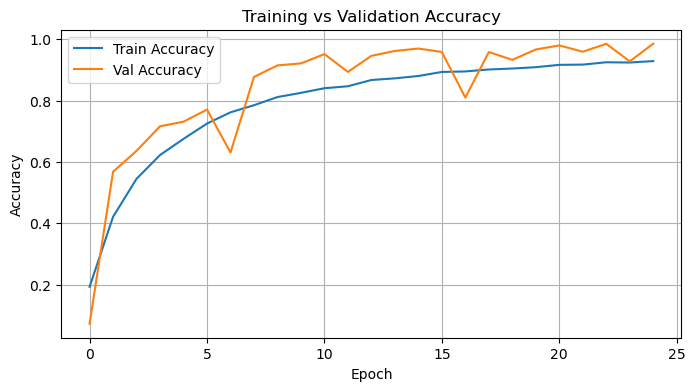

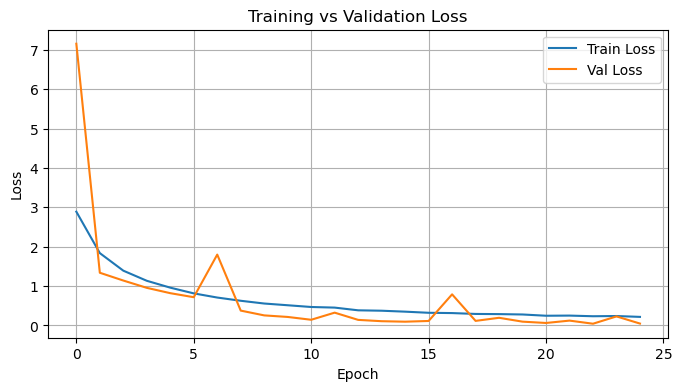

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
model.save("asl_sign_language_cnn_model.h5")
print("✅ Model saved successfully.")


✅ Model saved successfully.


In [19]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


Final Training Accuracy: 0.9285
Final Validation Accuracy: 0.9852
Final Training Loss: 0.2174
Final Validation Loss: 0.0478


In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import pickle
from collections import Counter

# === Load model and label encoder ===
model = load_model("asl_sign_language_cnn_model.h5")
with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

# === Constants ===
IMG_SIZE = 64
BOX_START = (150, 100)
BOX_SIZE = 300
prediction_history = []

# === Start Webcam ===
cap = cv2.VideoCapture(0)
print("🎥 Starting webcam... Show your ASL signs inside the green box.")
print("🔴 Press 'q' to exit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # mirror effect

    x1, y1 = BOX_START
    x2, y2 = x1 + BOX_SIZE, y1 + BOX_SIZE
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Crop and preprocess ROI
    roi = frame[y1:y2, x1:x2]
    img = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    preds = model.predict(img, verbose=0)
    pred_index = np.argmax(preds)
    pred_label = le.classes_[pred_index]
    confidence = preds[0][pred_index]

    # Apply prediction smoothing if confidence is high enough
    if confidence > 0.75:
        prediction_history.append(pred_label)
        if len(prediction_history) > 10:
            prediction_history.pop(0)
        most_common_pred = Counter(prediction_history).most_common(1)[0][0]
        avg_conf = np.mean([
            preds[0][le.classes_ == label][0]
            for label in prediction_history if label == most_common_pred
        ])
        text = f"{most_common_pred} ({avg_conf * 100:.1f}%)"
    else:
        text = "🤔 Not sure"
        prediction_history.clear()  # Reset on low confidence

    # Display prediction
    cv2.putText(frame, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("ASL Sign Prediction", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("🛑 Webcam closed.")


🎥 Starting webcam... Show your ASL signs inside the green box.
🔴 Press 'q' to exit.
🛑 Webcam closed.
